# Báo Cáo Thực Nghiệm và Phân Tích Hiệu Năng
Mục tiêu: Đánh giá thời gian chạy và độ ổn định số học của các phương pháp giải hệ $Ax = b$ (Gauss, QR, Gauss-Seidel).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from benchmark import generate_diagonally_dominant_system, evaluate_solver
from solvers import solve_gauss_custom, solve_qr_custom, solve_gauss_seidel_custom

warnings.filterwarnings("ignore")

## 1. Đánh giá thời gian thực thi (Đồ thị Log-Log)
Đo thời gian trung bình (5 lần chạy) với ma trận ngẫu nhiên kích thước $n \in \{50, 100, 200, 500, 1000\}$. So sánh thời gian thực tế với đường lý thuyết $O(n^3)$.

Đang đo hiệu năng thời gian...


,n,Khử Gauss_time,Khử Gauss_error,Phân rã QR_time,Phân rã QR_error,Gauss-Seidel_time,Gauss-Seidel_error
0,50,6.1581e-03,2.4927e-16,1.9328e-02,3.4999e-16,2.7603e-03,1.7812e-08
1,100,3.7350e-02,3.4470e-16,1.7401e-01,4.6124e-16,1.9041e-02,2.5631e-08
2,200,5.6150e-01,5.6047e-16,1.3043e+00,5.8303e-16,4.1711e-02,3.1348e-08
3,500,6.5490e+00,9.3938e-16,2.4988e+01,9.5456e-16,4.8364e-01,3.1080e-08
4,1000,5.3094e+01,1.2656e-15,2.1105e+02,1.2277e-15,1.3513e+00,3.3785e-08


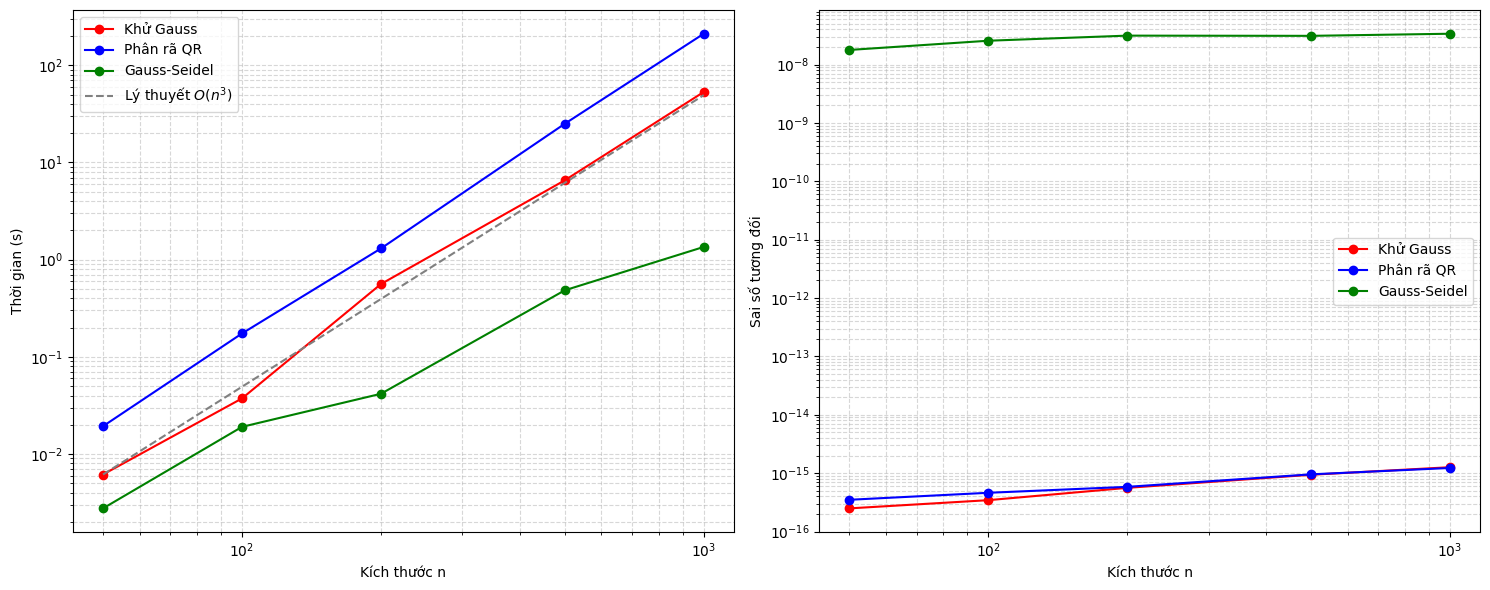

In [3]:
sizes = [50, 100, 200, 500, 1000]
methods_perf = {
    "Khử Gauss": solve_gauss_custom,
    "Phân rã QR": solve_qr_custom,
    "Gauss-Seidel": solve_gauss_seidel_custom
}

results_perf = []
print("Đang đo hiệu năng thời gian...")
for n in sizes:
    A, b = generate_diagonally_dominant_system(n)
    row = {"n": n}
    for name, func in methods_perf.items():
        try:
            t, err = evaluate_solver(func, A, b, num_runs=5)
            row[f"{name}_time"] = t
            row[f"{name}_error"] = err
        except:
            row[f"{name}_time"], row[f"{name}_error"] = np.nan, np.nan
    results_perf.append(row)

df_perf = pd.DataFrame(results_perf)

format_dict_perf = {col: "{:.4e}" for col in df_perf.columns if col != 'n'}
display(df_perf.style.format(format_dict_perf).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center !important'), ('white-space', 'nowrap')]}
]).set_properties(**{'text-align': 'center'}))

# --- VẼ ĐỒ THỊ HIỆU NĂNG ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors = {"Khử Gauss": "red", "Phân rã QR": "blue", "Gauss-Seidel": "green"}

for name in methods_perf.keys():
    axes[0].plot(df_perf["n"], df_perf[f"{name}_time"], 'o-', color=colors[name], label=name)
    axes[1].plot(df_perf["n"], df_perf[f"{name}_error"], 'o-', color=colors[name], label=name)

t_ref = (np.array(sizes)**3) * (df_perf["Khử Gauss_time"].iloc[0] / sizes[0]**3)
axes[0].plot(sizes, t_ref, '--', color='gray', label="Lý thuyết $O(n^3)$")

for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Kích thước n')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()

axes[0].set_ylabel('Thời gian (s)')
axes[1].set_ylabel('Sai số tương đối')

plt.tight_layout()
plt.show()

### **Nhận xét kết quả thực nghiệm**

Dựa trên đồ thị log-log, hai thuật toán giải trực tiếp là **Khử Gauss** và **Phân rã QR** đều bám sát đường lý thuyết $O(n^3)$, chứng tỏ việc cài đặt đã phản ánh đúng độ phức tạp thời gian mong đợi với sai số cực thấp ($\approx 10^{-15}$).

Ngược lại, phương pháp lặp **Gauss-Seidel** thể hiện tốc độ vượt trội với độ dốc thời gian thấp hơn hẳn, chuẩn xác với độ phức tạp $O(k \cdot n^2)$ trên ma trận chéo trội. Tuy nhiên, phương pháp này đánh đổi lại bằng mức sai số được neo ổn định ở $10^{-8}$ theo cấu hình điều kiện dừng $\epsilon$ thay vì đạt độ chính xác máy tính như các phương pháp trực tiếp.

## 2. Phân tích Ổn định Số học (Hilbert vs SPD)
Kiểm tra xem phương pháp QR xử lý thế nào khi gặp ma trận có số điều kiện (Condition Number) bùng nổ.

Đang phân tích độ ổn định (Hilbert vs SPD)...
không có pivot tại cột 10
hệ không có nghiệm duy nhất


,n,Cond(Hilbert),Sai số Gauss(H),Sai số QR(H),Cond(SPD),Sai số Gauss(SPD),Sai số QR(SPD)
0,3,5.2406e+02,0.0000e+00,1.8259e-14,2.1143e+00,9.5917e-17,1.5166e-16
1,5,4.7661e+05,8.0403e-17,3.4635e-11,2.6309e+00,1.3610e-16,1.9447e-16
2,7,4.7537e+08,1.1953e-16,1.4470e-06,2.9456e+00,0.0000e+00,1.6117e-16
3,9,4.9315e+11,5.3289e-17,5.4906e-07,3.5087e+00,1.3425e-16,2.2649e-16
4,11,5.2227e+14,nan,1.6406e-05,4.1053e+00,1.0944e-16,2.3399e-16


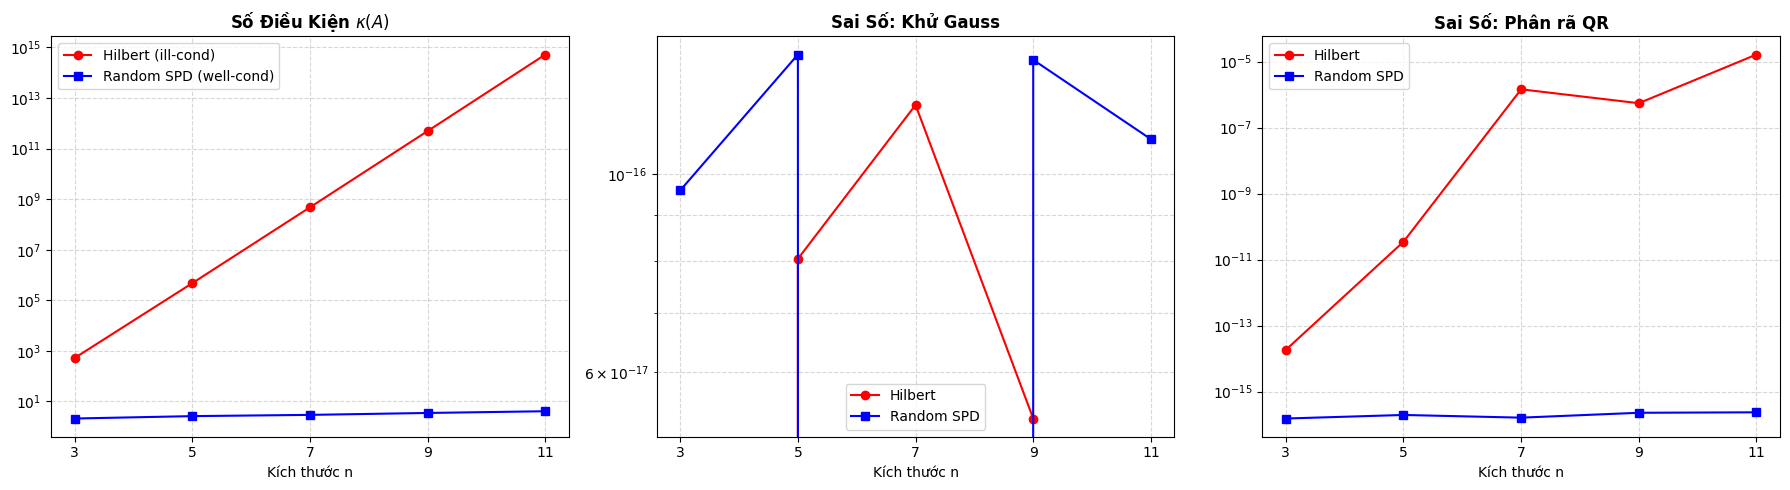

In [4]:
from benchmark import generate_hilbert_system, generate_spd_system

# --- THỰC NGHIỆM ĐỘ ỔN ĐỊNH ---
sizes_stab = [3, 5, 7, 9, 11]
results_stab = []

methods_stab = {
    "Gauss": solve_gauss_custom,
    "QR": solve_qr_custom
}

print("Đang phân tích độ ổn định (Hilbert vs SPD)...")
for n in sizes_stab:
    row = {"n": n}

    A_h, b_h = generate_hilbert_system(n)
    row["Cond(Hilbert)"] = np.linalg.cond(A_h)
    for name, func in methods_stab.items():
        try: _, err = evaluate_solver(func, A_h, b_h, num_runs=1)
        except: err = np.nan
        row[f"Sai số {name}(H)"] = err

    A_s, b_s = generate_spd_system(n)
    row["Cond(SPD)"] = np.linalg.cond(A_s)
    for name, func in methods_stab.items():
        try: _, err = evaluate_solver(func, A_s, b_s, num_runs=1)
        except: err = np.nan
        row[f"Sai số {name}(SPD)"] = err

    results_stab.append(row)

df_stab = pd.DataFrame(results_stab)

format_dict_stab = {col: "{:.4e}" for col in df_stab.columns if col != 'n'}
display(df_stab.style.format(format_dict_stab).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center !important'), ('white-space', 'nowrap')]}
]).set_properties(**{'text-align': 'center'}))


# --- VẼ 3 ĐỒ THỊ ỔN ĐỊNH ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_vals = df_stab["n"]

axes[0].plot(n_vals, df_stab["Cond(Hilbert)"], 'ro-', label='Hilbert (ill-cond)')
axes[0].plot(n_vals, df_stab["Cond(SPD)"], 'bs-', label='Random SPD (well-cond)')
axes[0].set_yscale('log')
axes[0].set_title('Số Điều Kiện $\kappa(A)$', fontweight='bold')

axes[1].plot(n_vals, df_stab["Sai số Gauss(H)"], 'ro-', label='Hilbert')
axes[1].plot(n_vals, df_stab["Sai số Gauss(SPD)"], 'bs-', label='Random SPD')
axes[1].set_yscale('log')
axes[1].set_title('Sai Số: Khử Gauss', fontweight='bold')

axes[2].plot(n_vals, df_stab["Sai số QR(H)"], 'ro-', label='Hilbert')
axes[2].plot(n_vals, df_stab["Sai số QR(SPD)"], 'bs-', label='Random SPD')
axes[2].set_yscale('log')
axes[2].set_title('Sai Số: Phân rã QR', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Kích thước n')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()
    ax.set_xticks(sizes_stab)

plt.tight_layout()
plt.show()

### **Nhận xét phân tích ổn định số**

**Ma trận Hilbert** là hệ cực kỳ kém điều kiện (ill-conditioned), khi $n$ tăng, số điều kiện $\kappa(A)$ bùng nổ theo cấp số nhân khiến sai số của thuật toán **Phân rã QR** cũng bị khuếch đại và tăng vọt lên mức $10^{-5}$. Trong khi đó, **Khử Gauss** thể hiện tính ổn định ngược tốt hơn đáng kể khi vẫn neo giữ được sai số ở mức $10^{-16}$.

Ngược lại, **ma trận SPD** luôn giữ được số điều kiện ở mức rất thấp (well-conditioned). Điều này tạo môi trường tính toán lý tưởng, giúp sai số của cả hai phương pháp giải luôn được duy trì ổn định ở mức tối thiểu ($\approx 10^{-16}$).